Loading spectral pattern data (4-pattern2.csv)...
Loading image features (image_features_mobilenet_large.csv)...

Spectral PCA: retained 9 components (PC1-9)
Cumulative explained variance: 0.9999

Image PCA: 186 components retained (95% variance)
Cumulative explained variance: 0.9503

Selected image PC indices: [0, 1, 2, 3, 4, 6, 7, 8, 10, 12, 15, 20, 22, 27, 29]
Number of selected image PCs: 15

Individual explained variance ratios of selected image PCs:
  PC0: 0.165763
  PC1: 0.076213
  PC2: 0.061389
  PC3: 0.046821
  PC4: 0.041484
  PC6: 0.029875
  PC7: 0.025066
  PC8: 0.020795
  PC10: 0.017860
  PC12: 0.015410
  PC15: 0.010990
  PC20: 0.008199
  PC22: 0.007745
  PC27: 0.006002
  PC29: 0.005536

Pearson Correlation Matrix (Spectral PC1-9 vs Selected Image PCs)
              Image_PC0  Image_PC1  Image_PC2  Image_PC3  Image_PC4  Image_PC6  Image_PC7  Image_PC8  Image_PC10  Image_PC12  Image_PC15  Image_PC20  Image_PC22  Image_PC27  Image_PC29
Spectral_PC1   0.587962   0.345167  -0.06

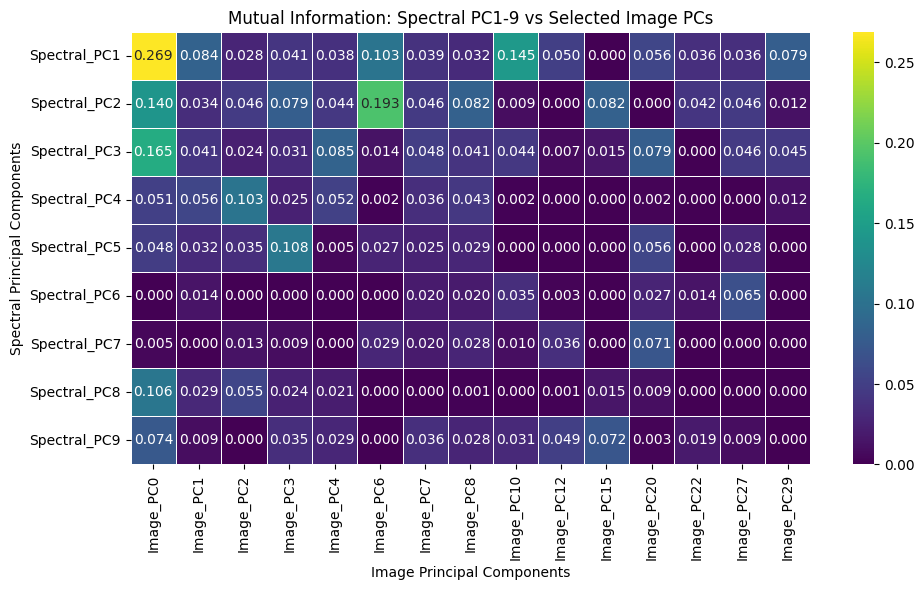


MI heatmap saved to: spectral_image_mi_heatmap.png


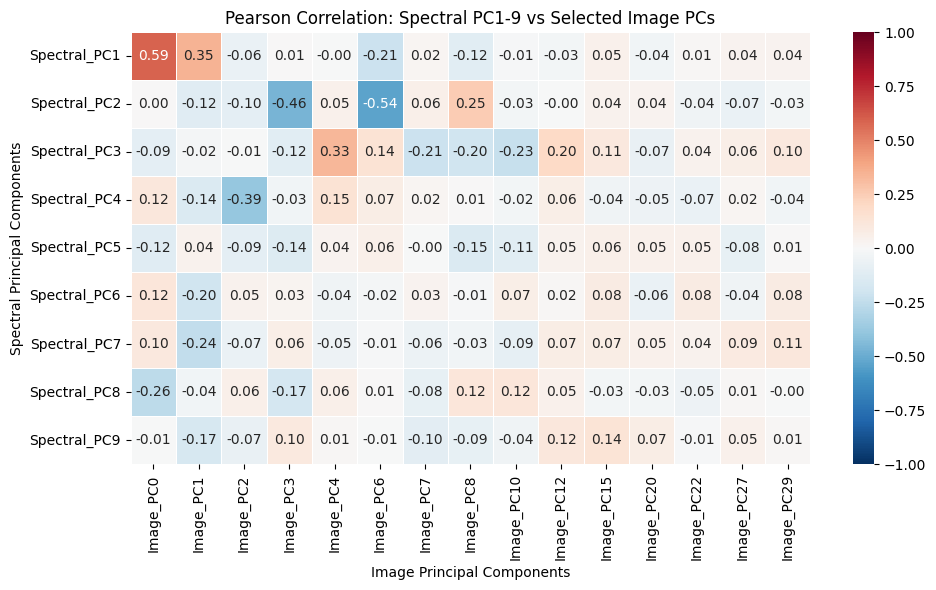


Pearson heatmap saved to: spectral_image_pearson_heatmap.png


In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading spectral pattern data (4-pattern2.csv)...")
pattern = pd.read_csv('4-pattern2.csv', header=None, encoding='utf-8-sig').values.astype('float64')
pattern = np.where(np.isinf(pattern), np.nan, pattern)
mean_val = np.nanmean(pattern) if not np.isnan(np.nanmean(pattern)) else 0
pattern = np.nan_to_num(pattern, nan=mean_val)

print("Loading image features (image_features_mobilenet_large.csv)...")
image_features = pd.read_csv('image_features_mobilenet_large.csv', header=None).values.astype('float64')

min_vals = np.min(pattern, axis=0)
max_vals = np.max(pattern, axis=0)
range_vals = np.where(max_vals - min_vals == 0, 1, max_vals - min_vals)
pattern_normalized = (pattern - min_vals) / range_vals

scaler_spectral = StandardScaler()
pattern_scaled = scaler_spectral.fit_transform(pattern_normalized)

pca_spectral = PCA(n_components=9)
pattern_spectral_pca = pca_spectral.fit_transform(pattern_scaled)
print(f"\nSpectral PCA: retained {pattern_spectral_pca.shape[1]} components (PC1-9)")
print(f"Cumulative explained variance: {np.sum(pca_spectral.explained_variance_ratio_):.4f}")

scaler_image = StandardScaler()
image_features_scaled = scaler_image.fit_transform(image_features)

pca_image = PCA(n_components=0.95)
pattern_image_pca_full = pca_image.fit_transform(image_features_scaled)
print(f"\nImage PCA: {pattern_image_pca_full.shape[1]} components retained (95% variance)")
print(f"Cumulative explained variance: {np.sum(pca_image.explained_variance_ratio_):.4f}")

selected_img_indices = [0, 1, 2, 3, 4, 6, 7, 8, 10, 12, 15, 20, 22, 27, 29]
n_img_components = pattern_image_pca_full.shape[1]

valid_indices = [idx for idx in selected_img_indices if idx < n_img_components]
if len(valid_indices) < len(selected_img_indices):
    missing = sorted(set(selected_img_indices) - set(valid_indices))
    print(f"\nWarning: Indices {missing} exceed image PCA dimension ({n_img_components}), they will be excluded.")
selected_img_indices = valid_indices

pattern_image_pca_selected = pattern_image_pca_full[:, selected_img_indices]
print(f"\nSelected image PC indices: {selected_img_indices}")
print(f"Number of selected image PCs: {len(selected_img_indices)}")

img_explained_var_ratio = pca_image.explained_variance_ratio_
print("\nIndividual explained variance ratios of selected image PCs:")
for idx in selected_img_indices:
    print(f"  PC{idx}: {img_explained_var_ratio[idx]:.6f}")

spec_feat = pattern_spectral_pca
img_feat = pattern_image_pca_selected

corr_matrix = np.zeros((spec_feat.shape[1], img_feat.shape[1]))
for i in range(spec_feat.shape[1]):
    for j in range(img_feat.shape[1]):
        corr, _ = pearsonr(spec_feat[:, i], img_feat[:, j])
        corr_matrix[i, j] = corr

corr_df = pd.DataFrame(
    corr_matrix,
    index=[f"Spectral_PC{i+1}" for i in range(spec_feat.shape[1])],
    columns=[f"Image_PC{idx}" for idx in selected_img_indices]
)

abs_corr = np.abs(corr_matrix)
max_corr = np.max(abs_corr)
mean_corr = np.mean(abs_corr)

print("\n" + "=" * 70)
print("Pearson Correlation Matrix (Spectral PC1-9 vs Selected Image PCs)")
print("=" * 70)
print(corr_df.to_string())

print("\nCorrelation Statistics:")
print(f"  Maximum absolute correlation: {max_corr:.4f}")
print(f"  Mean absolute correlation:    {mean_corr:.4f}")

if max_corr < 0.3 and mean_corr < 0.1:
    conclusion = "Very low linear correlation → minimal redundancy, strong complementarity."
    print(f"✓ Conclusion: {conclusion}")
elif max_corr < 0.3:
    conclusion = "Low maximum correlation, overall weak linear dependency."
    print(f"✓ Conclusion: {conclusion}")
else:
    conclusion = "Some linear dependencies exist."
    print(f"⚠ Conclusion: {conclusion}")

mi_matrix = np.zeros((spec_feat.shape[1], img_feat.shape[1]))
for i in range(spec_feat.shape[1]):
    for j in range(img_feat.shape[1]):
        mi = mutual_info_regression(spec_feat[:, i].reshape(-1, 1), img_feat[:, j])[0]
        mi_matrix[i, j] = mi

mi_df = pd.DataFrame(
    mi_matrix,
    index=[f"Spectral_PC{i+1}" for i in range(spec_feat.shape[1])],
    columns=[f"Image_PC{idx}" for idx in selected_img_indices]
)

print("\n" + "=" * 70)
print("Mutual Information Matrix (Spectral PC1-9 vs Selected Image PCs)")
print("=" * 70)
print(mi_df.to_string())

excel_file = 'spectral_image_correlation_results.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    corr_df.to_excel(writer, sheet_name='Pearson_Correlation', index=True)
    mi_df.to_excel(writer, sheet_name='Mutual_Information', index=True)
    
    img_pc_info = pd.DataFrame({
        'Image_PC_Index': selected_img_indices,
        'Explained_Variance': [img_explained_var_ratio[idx] for idx in selected_img_indices]
    })
    img_pc_info.to_excel(writer, sheet_name='Selected_Image_PC_Info', index=False)
    
    stats_df = pd.DataFrame({
        'Statistic': ['Max_abs_correlation', 'Mean_abs_correlation', 'Conclusion'],
        'Value': [f"{max_corr:.4f}", f"{mean_corr:.4f}", conclusion]
    })
    stats_df.to_excel(writer, sheet_name='Correlation_Statistics', index=False)
    
    spectral_pc_info = pd.DataFrame({
        'Spectral_PC': [f"PC{i+1}" for i in range(9)],
        'Explained_Variance': pca_spectral.explained_variance_ratio_,
        'Cumulative_Explained_Variance': np.cumsum(pca_spectral.explained_variance_ratio_)
    })
    spectral_pc_info.to_excel(writer, sheet_name='Spectral_PC_Info', index=False)

print(f"\nAll results exported to Excel file: {excel_file}")

plt.figure(figsize=(10, 6))
sns.heatmap(
    mi_df,
    annot=True,
    fmt=".3f",
    cmap='viridis',
    linewidths=0.5
)
plt.title('Mutual Information: Spectral PC1-9 vs Selected Image PCs')
plt.xlabel('Image Principal Components')
plt.ylabel('Spectral Principal Components')
plt.tight_layout()
mi_heatmap_file = 'spectral_image_mi_heatmap.png'
plt.savefig(mi_heatmap_file, dpi=150)
plt.show()
print(f"\nMI heatmap saved to: {mi_heatmap_file}")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Pearson Correlation: Spectral PC1-9 vs Selected Image PCs')
plt.xlabel('Image Principal Components')
plt.ylabel('Spectral Principal Components')
plt.tight_layout()
pearson_heatmap_file = 'spectral_image_pearson_heatmap.png'
plt.savefig(pearson_heatmap_file, dpi=150)
plt.show()
print(f"\nPearson heatmap saved to: {pearson_heatmap_file}")